## Set up the environment

In [ ]:
%load_ext autoreload
%autoreload 2
%matplotlib inline
from IPython.display import HTML, display

def set_css():
  display(HTML('''
  <style>
    pre {
        white-space: pre-wrap;
    }
  </style>
  '''))
get_ipython().events.register('pre_run_cell', set_css)

from google.colab import drive
drive.mount('/content/drive')
proj_dir = "/content/drive/MyDrive/Misinformation_Tutorial"

Mounted at /content/drive


In [ ]:
!pip install -U datasets huggingface_hub fsspec
!pip install bm25s

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.5/491.5 kB 26.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.6/193.6 kB 15.9 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2025.3.2
    Uninstalling fsspec-2025.3.2:
      Successfully uninstalled fsspec-2025.3.2
  Attempting uninstall: datasets
    Found existing installation: datasets 2.14.4
    Uninstalling datasets-2.14.4:
      Successfully uninstalled datasets-2.14.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2025.3.2 requires fsspec==2025.3.2, but you have fsspec 2025.3.0 which is incompatible.
torch 2.6.0+cu124 requires nvidia-cublas-cu12==12.4.5.8; platform_system == "Linux" and platform_machine == "x86_64", but you have nvidia-cublas-cu12 12.5.3.2 which is incompatible.
torch 2.6.0+cu124 requires nvidia-cuda-cupti-cu12==12.4.127; pl

In [ ]:
import gc
import torch
import pandas as pd
from datasets import Dataset, DatasetDict
from datasets import load_dataset
from sklearn.metrics import precision_recall_fscore_support
from matplotlib import pyplot as plt
import seaborn as sns
from typing import AnyStr
import numpy as np
from tqdm import tqdm

from transformers import TrainingArguments, Trainer
from transformers import AutoTokenizer, AutoModelForSequenceClassification, DataCollatorWithPadding

# Automated Fact Checking w/ NLP

This tutorial will cover the major steps of automated fact checking and how they are performed in practice.

## Outline

Automated fact checking is traditionally broken down into four steps:

1. **Claim detection**: automatically identifying statements **that should be evaluated as true or false**. The goal is to find sentences that present verifiable claims, as opposed to opinions, questions, or irrelevant information.

2. **Evidence retrieval**: given a claim to be fact checked, **find evidence which can be used to fact check the claim**. This requires one to first create a database with possible evidence (or one can retrieve evidence from a search engine), followed by searching over this database for each claim.

3. **Claim verification**: Given a claim to be fact checked and some evidence to check it against, **predict if the claim is true, false, or that there isn't enoug information to perform the fact check**.

4. **Explanation/justification**: After performing the fact check, **write an explanation which justifies the prediction**.

# PART 1: Claim Detection

<img src='https://drive.google.com/uc?id=1P9x2ydBsL5gqmEwJ9LTxE5ns7O3qGfWk'>

This part of the tutorial will cover claim (check-worthiness) detection.

We will go over what data is needed to train a model, popular evaluation datasets, and how to train your own model from scratch.

For this part of the tutorial, we'll cover the "old-school" methods. We will show how to use LLMs for later parts of the pipeline.


### Data
We'll use the check-worthiness detection data from the Clef CheckThat! shared task from 2024. The data consists of tweets and transcriptions of political speeches labeled for whether or not they are check-worthy.

Why is check-worthiness challenging?



> The aim of [Clef CheckThat!] is to determine whether a claim in a tweet and/or transcriptions is worth fact-checking. Typical approaches to make that decision require to either resort to the judgments of professional fact-checkers or to human annotators to answer several auxiliary questions such as “does it contain a verifiable factual claim?”, and “is it harmful?”, before deciding on the final check-worthiness label


The data (in multiple languages) can be found [here](https://gitlab.com/checkthat_lab/clef2024-checkthat-lab/-/tree/main/task1/data)



In [ ]:
# Download a dataset and upload it to drive, then load the data
train_data = pd.read_csv(f"{proj_dir}/data/CT24_checkworthy_english_train.tsv", sep='\t')
dev_data = pd.read_csv(f"{proj_dir}/data/CT24_checkworthy_english_dev.tsv", sep='\t')
test_data = pd.read_csv(f"{proj_dir}/data/CT24_checkworthy_english_dev-test.tsv", sep='\t')
train_data.head()


,Sentence_id,Text,class_label
0,30313,And so I know that this campaign has caused so...,No
1,19099,"Now, let's balance the budget and protect Medi...",No
2,33964,I'd like to mention one thing.,No
3,16871,I must remind him the Democrats have controlle...,Yes
4,13150,And to take a chance uh - now be - and not mak...,No


### Let's look at a couple of samples

In [ ]:
print("NOT Check-Worthy")
print(train_data.iloc[0]['Text'])

NOT Check-Worthy
And so I know that this campaign has caused some questioning and worries on the part of many leaders across the globe.


In [ ]:
print("Check-Worthy")
print(train_data.iloc[3]['Text'])

Check-Worthy
I must remind him the Democrats have controlled the Congress for the last twenty-two years and they wrote all the tax bills.


## Discuss: What makes a claim check-worthy?

The next step is to put the data in a format that we can use with [HuggingFace trainers.](https://huggingface.co/answerdotai/ModernBERT-large)

This involves:
- Loading a tokenizer for a model
- Creating a huggingface Dataset object from the original pandas dataframes
- Tokenizing the data and converting the labels to integers

In [ ]:
# Define which model we will use for training and inference.
# This is a modern version of the BERT architecture which we can download
# from huggingface
cw_model_name = "answerdotai/ModernBERT-large"

In [ ]:
# Create tokenier and mapping from sentences to tokens
tokenizer = AutoTokenizer.from_pretrained(cw_model_name)

# A function to map text inputs and text labels to tokens and integer labels
def map_data(examples):
    # Turn text labels into integer labels
    label_map = {
        'No': 0,
        'Yes': 1
    }
    # Tokenize the input text
    outputs = tokenizer(examples["Text"])
    outputs['label'] = label_map[examples['class_label']]
    return outputs


# Create a huggingface dataset
checkworthiness_dataset = DatasetDict()
# Add the pandas dataframes to the datasets
checkworthiness_dataset['train'] = Dataset.from_pandas(train_data)
checkworthiness_dataset['validation'] = Dataset.from_pandas(dev_data)
checkworthiness_dataset['test'] = Dataset.from_pandas(test_data)

checkworthiness_dataset = checkworthiness_dataset.map(map_data,
                                    remove_columns=checkworthiness_dataset['train'].column_names)


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/20.8k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.13M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/694 [00:00<?, ?B/s]

Map:   0%|          | 0/22501 [00:00<?, ? examples/s]

Map:   0%|          | 0/1032 [00:00<?, ? examples/s]

Map:   0%|          | 0/318 [00:00<?, ? examples/s]

### Evaluation method

We will evaluate the performance of the model using binary F1 score.

In [ ]:
# Define an evaluation function
def evaluate_binary(eval_pred):
  """
  A function to perform binary F1 evaluation
  :param: eval_pred -- A tuple containing the logits produced by a model and
      the gold labels for the corresponding samples
  :returns: A dict with the precision, recall, and F1 scores
  """
  logits, labels = eval_pred
  # convert the logits to their predicted class
  predictions = np.argmax(logits, axis=-1)
  metrics =  precision_recall_fscore_support(
      y_pred=predictions, y_true=labels, average='binary')
  return {
      'precision': metrics[0],
      'recall': metrics[1],
      'f1': metrics[2]
  }

### Training

The code below shows in detail how to fine-tune a model for check-worthiness detection. Feel free to go through it on your own if interested!

Training using the HuggingFace API involves four steps:

- Create a TrainingArguments object and set the hyperparameters for training
- Load the model from the HuggingFace hub
- Create a Trainer object
- Run training and save the best model

If you do not want to train from scratch, simply execute the cell as is! Otherwise, se the parameter "train_from_scratch" to True!

In [ ]:
# Set this to True if you want to run training on your own!
train_from_scratch = False

In [ ]:
# Define training arguments
training_args = TrainingArguments(
    output_dir=f"{proj_dir}/models",
    eval_strategy="epoch",
    num_train_epochs=5,
    per_device_train_batch_size=8,
    report_to="none",
    load_best_model_at_end=True,
    save_strategy='epoch'
)

if train_from_scratch:
  ################ Train from scratch! #####################
  # Create a model
  model = AutoModelForSequenceClassification.from_pretrained(
      cw_model_name, num_labels=2)

  # Create a trainer
  trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=checkworthiness_dataset["train"],
    eval_dataset=checkworthiness_dataset["validation"],
    compute_metrics=evaluate_binary,
    data_collator=DataCollatorWithPadding(tokenizer, return_tensors='pt')
  )

  # Train!
  trainer.train()
  trainer.save_model(f"{proj_dir}/models/cw_base")
##########################################################################
else:
  ################ Otherwise, load a pretrained model! #####################

  model = AutoModelForSequenceClassification.from_pretrained(
    "dwright37/icwsm_cw_base", num_labels=2)

  # Create a trainer
  trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=checkworthiness_dataset["train"],
    eval_dataset=checkworthiness_dataset["validation"],
    compute_metrics=evaluate_binary,
    data_collator=DataCollatorWithPadding(tokenizer, return_tensors='pt')
  )

config.json:   0%|          | 0.00/1.36k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.58G [00:00<?, ?B/s]

In [ ]:
# Evaluate on the test set
# We set the evaluation function when we created the Trainer object to be our
# evaluation method
trainer.evaluate(checkworthiness_dataset["test"])

W0620 09:12:13.501000 500 torch/_inductor/utils.py:1137] [1/0] Not enough SMs to use max_autotune_gemm mode


{'eval_loss': 0.4167173504829407,
 'eval_model_preparation_time': 0.0064,
 'eval_precision': 0.9367088607594937,
 'eval_recall': 0.6851851851851852,
 'eval_f1': 0.7914438502673797,
 'eval_runtime': 14.7932,
 'eval_samples_per_second': 21.496,
 'eval_steps_per_second': 2.704}

So, we get the following results:

**Precision** -- 93.67

**Recall** -- 68.51

**F1** -- 79.14

This means that when the model predicts a claim is check-worthy, oftentimes this is correct. However, the model misses *many* check-worthy claims. Why is this?

One thing to note about check-worthiness data -- there tends to be strong label imbalance.

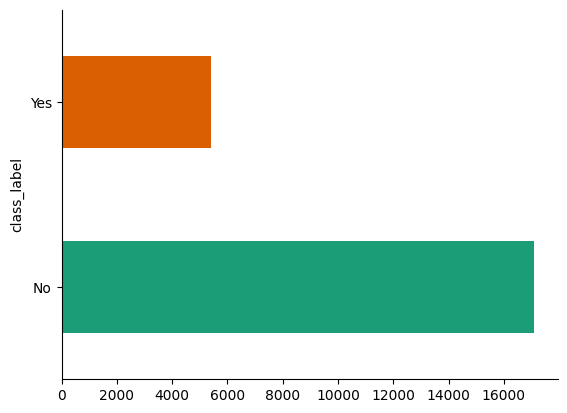

In [ ]:
# Plot the label distribution
train_data.groupby('class_label').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

We can improve performance by *a lot* if we take this label imbalance into account!

You can try the code below on your own and look through it if you want to see how to make a classifier that takes label imbalance into account.

The results are much better!

**Precision** -- 86.24

**Recall** -- 87.04

**F1** -- 86.64

This is an improvement 7 F1 points! This is also mainly driven by an large improvement in recall, without losing much precision.

## EXTRA: Accounting for label imbalance

This does okay, but can we do better?

Check-worthiness datasets are usually heavily imbalanced.

Let's train a new model which takes this into account!

We can do this by making our own custom Trainer object which
uses a weighted cross entropy loss.

In [ ]:
# Make a trainer which takes a custom loss function
class CustomLossTrainer(Trainer):
    def __init__(self, *args, loss_fn=None, **kwargs):
        super().__init__(*args, **kwargs)
        # Store your custom loss function.
        # This should take (logits, labels) as arguments.
        self.loss_fn = loss_fn

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        # Assume your inputs include "labels" and your model returns logits.
        labels = inputs.get("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")

        # Compute the custom loss using your loss function.
        loss = self.loss_fn(logits, labels)

        return (loss, outputs) if return_outputs else loss

Add some description about calculating the label imbalance

In [ ]:
# Calculate the class weights based on the imbalance
labels = checkworthiness_dataset["train"]['label']
weight = torch.tensor(len(labels) / (2 * np.bincount(labels)))
class_weights = weight.type(torch.FloatTensor).to("cuda")

# Create the loss function based on this
loss_fn = torch.nn.CrossEntropyLoss(weight=class_weights)

In [ ]:
train_from_scratch = False

In [ ]:
# Clean up the old model
del model
gc.collect()
torch.cuda.empty_cache()

if train_from_scratch:
  # Create a new model
  model = AutoModelForSequenceClassification.from_pretrained(
      cw_model_name, num_labels=2)

  # Now run training with this new loss
  trainer = CustomLossTrainer(
    model=model,
    args=training_args,
    train_dataset=checkworthiness_dataset["train"],
    eval_dataset=checkworthiness_dataset["validation"],
    compute_metrics=evaluate_binary,
    data_collator=DataCollatorWithPadding(tokenizer, return_tensors='pt'),
    loss_fn=loss_fn
  )

  # Train!
  trainer.train()
  trainer.save_model(f"{proj_dir}/models/cw_weighted")
else:
  model = AutoModelForSequenceClassification.from_pretrained(
    "dwright37/icwsm_cw_weighted", num_labels=2)

  # Create a trainer
  trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=checkworthiness_dataset["train"],
    eval_dataset=checkworthiness_dataset["validation"],
    compute_metrics=evaluate_binary,
    data_collator=DataCollatorWithPadding(tokenizer, return_tensors='pt')
  )

config.json:   0%|          | 0.00/1.19k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.58G [00:00<?, ?B/s]

Some weights of ModernBertForSequenceClassification were not initialized from the model checkpoint at answerdotai/ModernBERT-large and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Precision,Recall,F1
1,0.448800,0.124022,0.839416,0.966387,0.898438
2,0.389000,0.113640,0.933333,0.941176,0.937238
3,0.245600,0.151633,0.948052,0.920168,0.933902
4,0.100700,0.144063,0.961538,0.945378,0.953390


In [ ]:
# Evaluate on the test set
trainer.evaluate(checkworthiness_dataset["test"])

{'eval_loss': 0.20393489301204681,
 'eval_model_preparation_time': 0.0375,
 'eval_precision': 0.8623853211009175,
 'eval_recall': 0.8703703703703703,
 'eval_f1': 0.8663594470046083,
 'eval_runtime': 8.6026,
 'eval_samples_per_second': 36.966,
 'eval_steps_per_second': 4.65}

# PART 2: Evidence Retrieval

<img src='https://drive.google.com/uc?id=1ar3ukXjvgfngEZy4Z2J1cM-2t_F2TF8U'>

Evidence retrieval involves the following:

- Create a database of potential evidence to search over
- Vectorize the evidence for fast retrieval
- Given a claim, vectorize the claim
- Rank each piece of evidence based on its similarity to the claim, using some
vector similarity metric

We will look at two ways to vectorize our text: BM25 and Sentence Transformers.

## Discuss: What data would you use as an evidence corpus?

In [ ]:
from collections import defaultdict
import bm25s

topk = 10

### Dataset

For the rest of the tutorial we will rely on the [FEVER dataset](https://arxiv.org/abs/1803.05355), which contains fact check-worthy claims paired with factuality labels. The evidence set comes from a large wikipedia dump.

For the sake of the tutorial, we will use the following dataset, which has gold evidence paired with the claims needed to fact check them: [https://huggingface.co/datasets/copenlu/fever_gold_evidence](https://huggingface.co/datasets/copenlu/fever_gold_evidence)

In [ ]:
# Download the initial evidence dataset
original_fever = load_dataset("copenlu/fever_gold_evidence")
original_fever

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/5.19k [00:00<?, ?B/s]

train.jsonl:   0%|          | 0.00/96.9M [00:00<?, ?B/s]

valid.jsonl:   0%|          | 0.00/6.47M [00:00<?, ?B/s]

test.jsonl:   0%|          | 0.00/6.63M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/228277 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/15935 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/16039 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['claim', 'label', 'evidence', 'id', 'verifiable', 'original_id'],
        num_rows: 228277
    })
    validation: Dataset({
        features: ['claim', 'label', 'evidence', 'id', 'verifiable', 'original_id'],
        num_rows: 15935
    })
    test: Dataset({
        features: ['claim', 'label', 'evidence', 'id', 'verifiable', 'original_id'],
        num_rows: 16039
    })
})

The 'evidence' column contains lists of evidence snippets, including the title of the original wikipedia article, section number, and evidence text.

In [ ]:
original_fever['train']['evidence'][4]

[['The_World_According_to_Paris',
  '4',
  "It was filmed from November 2010 , with Hilton 's court-ordered community service stemming from her arrest in Las Vegas , Nevada for cocaine possession , to February 2011 , with her birthday party , the series co-starred Brooke Mueller , Lexi Dreyfus , Jennifer Rovero , Allison Melnick , Brooke Brinson -LRB- daughter of Kim Richards -RRB- , Hilton 's then-boyfriend Cy Waits , and Kathy Hilton ."]]

Let's create a flat database of evidence texts to use for retrieval.

In [ ]:
evidence_flat = {}
# Store the claims as well
claim_to_gold_id = defaultdict(list)
id_ = 0
for split in original_fever:
  for evidence_set,claim in zip(original_fever[split]['evidence'],original_fever[split]['claim']):
    for evidence in evidence_set:
      if evidence[-1] in evidence_flat:
        claim_to_gold_id[claim].append(evidence_flat[evidence[-1]])
      else:
        evidence_flat[evidence[-1]] = id_
        claim_to_gold_id[claim].append(id_)
        id_ += 1

We will test two different ways to retrieve evidence: BM25 and Sentence Transformers

Both methods are based on a similar concept: turn each piece of text (claims and evidence) into **vectors**, and rank each piece of evidence based on its vector similarity to a given claim.

The difference between the two methods lie in *how* they turn text into vectors.

### Sentence Vectorization

<img src='https://drive.google.com/uc?id=1PDMDkVt5aeZUf7h81I50h7wqM4dZfGpq'>


### BM25

BM25 is a **bag-of-words** retrieval method.

This means that it is based on the relative frequencies of different words appearing in each piece of text.

At a *very* high level, it works as follows:

You start with a corpus of text, from which a vocabulary $V$ is constructed, and the statistics of each word in the vocabulary are caluculated.

Then, a given piece of text is turned in the a vector of size $V$, where each index is the index of a word in the vocabulary. The value at each index is calculated based on the frequency of each word in the supplied text relative to the frequency if that word in the original corpus.

In [ ]:
# First, index the corpus of evidence
corpus = list(evidence_flat.keys())
retriever = bm25s.BM25(corpus=corpus)
retriever.index(bm25s.tokenize(corpus))

Split strings:   0%|          | 0/67437 [00:00<?, ?it/s]

DEBUG:bm25s:Building index from IDs objects


BM25S Count Tokens:   0%|          | 0/67437 [00:00<?, ?it/s]

BM25S Compute Scores:   0%|          | 0/67437 [00:00<?, ?it/s]

In [ ]:
# Now we can try to do some retrieval

# Specify a claim
claim = original_fever['train']['claim'][0]

print("CLAIM")
print("=====")
print(claim)
print()

# Retrieve the top 10 results
results, scores = retriever.retrieve(bm25s.tokenize(claim), k=topk)

print("EVIDENCE")
print("=====")
for sent in results[0]:
  print(sent)
  print()

CLAIM
=====
The number of new cases of shingles per year extends from 1.2–3.4 per 1,000 among healthy individuals.



Split strings:   0%|          | 0/1 [00:00<?, ?it/s]

BM25S Retrieve:   0%|          | 0/1 [00:00<?, ?it/s]

EVIDENCE
=====
The number of new cases per year ranges from 1.2 -- 3.4 per 1,000 among healthy individuals to 3.9 -- 11.8 per 1,000 among those older than 65 years of age .

List of countries by intentional homicide rate per year per 100,000 inhabitants .

The crude birth rate is the number of live births per year per 1,000 midyear population Another term used interchangeably with birth rate is natality .

The infant mortality rate in 2011 was 41 per 1,000 births , with an under-five mortality rate at 61 per 1,000 births .

It occurs in about 2.1 per 1,000 live births .

Rates of disease vary between countries from 20 to 70 per 100,000 .

Election to the AAP is an honor extended to individuals with outstanding credentials in biomedical science and/or translational biomedical research , and is limited to 60 persons per year .

Regarding this issue , Nick Clegg has said that `` There are hundreds of people earning millions per year who are barely paying 20 per cent tax , forget 40 per ce

### Sentence Transformers

<img src='https://drive.google.com/uc?id=1nZouGErNgE4uHlbJ3m1Hup0VbaKd75-L'/>

Sentence transformers turn pieces of text into vectors based on their *semantics*. In other words, pieces of text which convey the same meaning will result in vectors which are close to each other, while this with dissimilar meaning will be far away. These vectors are also referred to as **embeddings**.

Sentence transformers produce embeddings by using BERT as a feature extractor. The base BERT model is fine-tuned by comparing billions of pairs of text and optimizing the base BERT network with an objective function which causes the features of similar pieces of text to be close in the feature space, and different pieces of text to be far away in the embedding space.

For more details, please see [this paper](https://arxiv.org/pdf/1908.10084) or read [the documentation](https://sbert.net/).


In [ ]:
from sentence_transformers import SentenceTransformer
from sentence_transformers.util import cos_sim

# Load the pre-trained model
model = SentenceTransformer('all-MiniLM-L6-v2')

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [ ]:
# Create embeddings of the evidence
evidence_embeddings = model.encode(corpus)

In [ ]:
print("CLAIM")
print("=====")
print(claim)
print()

# Get an embedding of a claim
claim_embedding = model.encode([claim])

# Measure the cosine similarity with the evidence corpus
similarities = cos_sim(claim_embedding, evidence_embeddings)

# Similarities is a vector with all of the cosine similarities; get the top k pieces of evidence
top_indices = np.argsort(similarities[0].numpy())[::-1][:topk]

results = [corpus[idx] for idx in top_indices]

print("EVIDENCE")
print("=====")
for sent in results:
  print(sent)
  print()

CLAIM
=====
The number of new cases of shingles per year extends from 1.2–3.4 per 1,000 among healthy individuals.

EVIDENCE
=====
It is estimated that about a third of people develop shingles at some point in their life .

The number of new cases per year ranges from 1.2 -- 3.4 per 1,000 among healthy individuals to 3.9 -- 11.8 per 1,000 among those older than 65 years of age .

The shingles vaccine decreases the chance of shingles by about half in those between the ages of 50 and 80 .

Shingles , also known as herpes zoster , is a viral disease characterized by a painful skin rash with blisters in a localized area .

In 2007 there were an estimated 13.7 million chronic active cases , and in 2010 there were 8.8 million new cases , and 1.45 million deaths , mostly in developing countries .

It causes chickenpox -LRB- varicella -RRB- , a disease most commonly affecting children , teens and young adults and herpes zoster -LRB- shingles -RRB- in older adults ; shingles is rare in children

### Evaluation

How do we evaluate if our evidence retrieval system is working well?

The output of our retrieval system will be a **ranked list** of pieces of evidence. When we have access to **gold evidence** (i.e., evidence that we know is relevant for the fact check), we can evaluate our system based on how highly the relevant evidence is ranked.

#### Unranked evidence
|Evidence ID|Relevant?|
|-----------|---------|
|EV1|0|
|EV2|1|
|EV3|0|
|EV4|1|
|EV5|0|

#### After retrieval
|Evidence ID|Relevant?|
|-----------|---------|
|EV4|1|
|EV5|0|
|EV2|1|
|EV3|0|
|EV1|0|

There are many metrics one can use for this; in this tutorial we will use Mean Reciprocal Rank.

The implementation of this metric (and more) can be found here: https://gist.github.com/bwhite/3726239

In [ ]:
def mean_reciprocal_rank(rs):
    """Score is reciprocal of the rank of the first relevant item
    First element is 'rank 1'.  Relevance is binary (nonzero is relevant).
    Example from http://en.wikipedia.org/wiki/Mean_reciprocal_rank
    >>> rs = [[0, 0, 1], [0, 1, 0], [1, 0, 0]]
    >>> mean_reciprocal_rank(rs)
    0.61111111111111105
    >>> rs = np.array([[0, 0, 0], [0, 1, 0], [1, 0, 0]])
    >>> mean_reciprocal_rank(rs)
    0.5
    >>> rs = [[0, 0, 0, 1], [1, 0, 0], [1, 0, 0]]
    >>> mean_reciprocal_rank(rs)
    0.75
    Args:
        rs: Iterator of relevance scores (list or numpy) in rank order
            (first element is the first item)
    Returns:
        Mean reciprocal rank
    """
    rs = (np.asarray(r).nonzero()[0] for r in rs)
    return np.mean([1. / (r[0] + 1) if r.size else 0. for r in rs])

### Compare BM25 and Sentence Transformers on the retrieval task


In [ ]:
# Get BM25 results for first 1000 claims
claims = list(claim_to_gold_id.keys())[:1000]
results, scores = retriever.retrieve(bm25s.tokenize(claims), k=topk)
# Get a binary indicator if each piece of evidence is in the claim's gold set
retrieval_vectors = [[int(evidence_flat[ev] in claim_to_gold_id[claim]) for ev in evidences] for claim,evidences in zip(claims,results)]
# Print metrics
print(f"BM25 MRR: {mean_reciprocal_rank(retrieval_vectors)}")


Split strings:   0%|          | 0/1000 [00:00<?, ?it/s]

BM25S Retrieve:   0%|          | 0/1000 [00:00<?, ?it/s]

BM25 MRR: 0.5244599206349206


In [ ]:
# Get transformer results for first 1000 claims
claim_embeddings = model.encode(claims)

# Measure the cosine similarity with the evidence corpus
similarities = cos_sim(claim_embeddings, evidence_embeddings)

# Similarities is a vector with all of the cosine similarities; get the top k pieces of evidence
top_indices = np.argsort(similarities.numpy(), axis=1)[:,::-1][:,:topk]

results = [[corpus[idx] for idx in curr] for curr in top_indices]
# Get a binary indicator if each piece of evidence is in the claim's gold set
retrieval_vectors = [[int(evidence_flat[ev] in claim_to_gold_id[claim]) for ev in evidences] for claim,evidences in zip(claims,results)]

print(f"Transformers MRR: {mean_reciprocal_rank(retrieval_vectors)}")


Transformers MRR: 0.565011507936508


## Discuss: What are some pros and cons between bag-of-words and semantic approaches? Why would semantic work better?

# PART 3: Claim Verification

<img src='https://drive.google.com/uc?id=1swWucmrV8NywVPiDEDYjdpa5TEQG5Kba'>


The third step in automatic fact checking is claim verification.

Claim verification involves two steps:

1. Given a claim, retrieve evidence which either supports or refutes the claim.
2. Determine if the evidence SUPPORT or REFUTES the claim, or if there is NOT ENOUGH INFORMATION.

In [ ]:
# Show examples of claims and their labels
for k in [0,2,3]:
  print(f"Claim: {original_fever['train']['claim'][k]}")
  print(f"Label: {original_fever['train']['label'][k]}")
  print(f"Evidence: {original_fever['train']['evidence'][k]}")
  print()

Claim: The number of new cases of shingles per year extends from 1.2–3.4 per 1,000 among healthy individuals.
Label: SUPPORTS
Evidence: [['Shingles', '31', 'The number of new cases per year ranges from 1.2 -- 3.4 per 1,000 among healthy individuals to 3.9 -- 11.8 per 1,000 among those older than 65 years of age .']]

Claim: Eleveneleven was founded by a chef.
Label: REFUTES
Evidence: [['Eleveneleven', '0', 'eleveneleven is a record label founded in 2010 by Mike Hamlin , Ellen DeGeneres and her production company , A Very Good Production , in association with longtime affiliate Warner Bros. .']]

Claim: Cosmos: A Spacetime Odyssey secured studio support thanks to Seth MacFarlane.
Label: NOT ENOUGH INFO
Evidence: [['Seth_MacFarlane', '21', 'MacFarlane served as executive producer of Cosmos : A Spacetime Odyssey , an update of the 1980s Carl Sagan -- hosted Cosmos series , hosted by Neil deGrasse Tyson .']]



We'll use a pre-trained model for this and compare to using a large language model (LLM)

In [ ]:
from transformers import pipeline

N = 1000
#Create the pipeline using a good pretrained model
inference_pipeline = pipeline("text-classification", model="ynie/roberta-large-snli_mnli_fever_anli_R1_R2_R3-nli")

config.json:   0%|          | 0.00/703 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.43G [00:00<?, ?B/s]

Some weights of the model checkpoint at ynie/roberta-large-snli_mnli_fever_anli_R1_R2_R3-nli were not used when initializing RobertaForSequenceClassification: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
- This IS expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


model.safetensors:   0%|          | 0.00/1.43G [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/772 [00:00<?, ?B/s]

Device set to use cuda:0


## Input

The input data to the pipeline is a list of dictionaries.

Each dictionary has two items:

`text`: The evidence that we are using for the fact check.

`text_pair`: The claim that we are fact checking.

The pipeline will the return a list of predictions, where each prediction has a label and a score (probability of that label).

The model that we are using has been trained on many different datasets for the more general task of natural language inference, which tries to predict if the `text_pair` sentence is absolutely and full entailed by the `text`.

Therefore, we will need to map all of the dataset labels and prediction labels to a common set of labels. In this case, we will map `SUPPORTS` and `entailment` to 0, `REFUTES` and `contradiction` to 1 and `NOT ENOUGH INFO` and `neutral` to 2.

In [ ]:
# Let's first create the input dataset
inference_data = []
labels = []
fever_label_map = {
    'SUPPORTS': 0,
    'REFUTES': 1,
    'NOT ENOUGH INFO': 2
}
for k in tqdm(range(N)):
  claim = original_fever['test']['claim'][k]
  labels.append(fever_label_map[original_fever['test']['label'][k]])

  evidence = '\n'.join([ev[-1] for ev in original_fever['test']['evidence'][k]])

  # The huggingface pipeline input expects a dictionary with two fields: 'text' and 'text_pair',
  # corresponding to the evidence and the claim, respectively.
  inference_data.append({
      'text': evidence,
      'text_pair': claim
  })


100%|██████████| 1000/1000 [03:49<00:00,  4.36it/s]


In [ ]:
# Run the data through the pipeline
predictions = inference_pipeline(inference_data)

In [ ]:
# Print the predictions
predictions[:10]

[{'label': 'neutral', 'score': 0.4881078600883484},
 {'label': 'contradiction', 'score': 0.9624104499816895},
 {'label': 'contradiction', 'score': 0.8050504326820374},
 {'label': 'neutral', 'score': 0.9935916066169739},
 {'label': 'entailment', 'score': 0.9975146055221558},
 {'label': 'contradiction', 'score': 0.9933522939682007},
 {'label': 'neutral', 'score': 0.9089121222496033},
 {'label': 'neutral', 'score': 0.8626668453216553},
 {'label': 'neutral', 'score': 0.8724485039710999},
 {'label': 'entailment', 'score': 0.9626972675323486}]

In [ ]:
# We have to map them to the same label space
pipeline_label_map = {
    'entailment': 0,
    'contradiction': 1,
    'neutral': 2
}
predictions = [pipeline_label_map[p['label']] for p in predictions]

In [ ]:
# Evaluate with accuracy
def accuracy(preds, labels):
  return (np.array(preds) == np.array(labels)).mean() * 100

print(f"Accuracy: {accuracy(predictions, labels)}")

Accuracy: 83.2


## Discuss: Would you use this system in practice? How accurate should a fact verification system be?

### Claim verification with large language models

We can also perform the claim verification task with an LLM.

Here we will show how to use GPT 4o mini for claim verification.

We use prompts from this recent paper at the FEVER workshop: https://github.com/ronit-singhal/evidence-backed-fact-checking-using-rag-and-few-shot-in-context-learning-with-llms

In [ ]:
# First, set up openai with credentials
from openai import OpenAI
import json

with open(f"{proj_dir}/oai/credentials.json") as f:
  credentials = json.load(f)

oai = OpenAI(**credentials)

### Zero-shot setup

In this example, we will simply prompt GPT 4o mini with the claim and evidence statements, with some basic instructions about how to label each example.

In [ ]:
# Set up the prompt for fact checking
ZERO_SHOT_PROMPT_TEMPLATE = """
You are tasked with classifying a given claim based on provided statements into one of the following three categories:
1. SUPPORTS: If there is sufficient evidence indicating that the claim is legitimate, classify it as SUPPORTS.
2. REFUTES: If there is any evidence contradicting the claim, classify it as REFUTES.
3. NOT ENOUGH INFO: If you cannot find any conclusive factual evidence either supporting or refuting the claim, classify it as NOT ENOUGH INFO.
This means the available information is insufficient to make a definitive judgment.

Claim: {claim}
Statements: {statements}

Pick only one from ['SUPPORTS', 'REFUTES', 'NOT ENOUGH INFO']
Do not print anything other than the final classification.
"""

gpt_label_map = {
    'SUPPORTS': 0,
    'REFUTES': 1,
    'NOT ENOUGH INFO': 2
}

In [ ]:
# Set up the zero-shot prompts
zero_shot_inference_data = []
labels = []

#for k in tqdm(range(len(original_fever['test']['claim']))):
for k in tqdm(range(N)):

  # This first part is exactly the same as before
  claim = original_fever['test']['claim'][k]
  labels.append(fever_label_map[original_fever['test']['label'][k]])
  evidence = '\n'.join([ev[-1] for ev in original_fever['test']['evidence'][k]])

  # Here we put the claim and retrieved statements into the prompt
  prompt_curr = ZERO_SHOT_PROMPT_TEMPLATE.replace("{claim}", claim).replace("{statements}", evidence)

  # Add the propt to the list in the format which the oai package expects
  zero_shot_inference_data.append([{
      'role': 'user',
      'content': prompt_curr
  }])

100%|██████████| 1000/1000 [03:21<00:00,  4.96it/s]


In [ ]:
print(zero_shot_inference_data[0][0]['content'])


You are tasked with classifying a given claim based on provided statements into one of the following three categories:
1. SUPPORTS: If there is sufficient evidence indicating that the claim is legitimate, classify it as SUPPORTS.
2. REFUTES: If there is any evidence contradicting the claim, classify it as REFUTES.
3. NOT ENOUGH INFO: If you cannot find any conclusive factual evidence either supporting or refuting the claim, classify it as NOT ENOUGH INFO.
This means the available information is insufficient to make a definitive judgment.

Claim: Kareena Kapoor was a commercial failure.
Statements: This initial success was followed by a series of commercial failures and repetitive roles , which garnered her negative reviews .

Pick only one from ['SUPPORTS', 'REFUTES', 'NOT ENOUGH INFO']
Do not print anything other than the final classification.



In [ ]:
# Define a function to get responses from open AI for claim verification
def predict_openai(inference_data):
  # Now generate with GPT 4o mini!
  predictions = []
  for msgs in tqdm(zero_shot_inference_data):
    # Get a response from GPT 4o mini
    completion = oai.chat.completions.create(
                  model='gpt-4o-mini',
                  messages=msgs,
                  temperature=1.,
                  max_tokens=10,
                  top_p=0.9,
                  n=1
              )
    # Extract the raw text of the result, clear off whitespace and make it all uppercase
    # since this is how we have set up our labels
    raw_result = completion.choices[0].message.content.strip().upper()
    # Get the label from our label map; if the returned label is not in our set of labels, set it to
    # NOT ENOUGH INFO
    predictions.append(gpt_label_map[raw_result] if raw_result in gpt_label_map else gpt_label_map['NOT ENOUGH INFO'])

  return predictions

In [ ]:
predictions = predict_openai(zero_shot_inference_data)

100%|██████████| 1000/1000 [11:30<00:00,  1.45it/s]


In [ ]:
print(f"Zero-shot LLM accuracy: {accuracy(predictions, labels)}")

Zero-shot LLM accuracy: 79.60000000000001


# PART 4: Justification/Explanation

<img src='https://drive.google.com/uc?id=1rIclhuZa4ISAiZ-2waYcITvfNsQekVMW'>

Finally, after predicting if a claim is true or false, we need to provide an explanation/justification for *why* this is the case.

For this we will turn to GPT 4o mini again and prompt it to generate an explanation for a few examples.

We'll first show some examples of generated explanations, followed by how to use LLM-as-a-judge to evaluate the faithfulness of the explanations.

In [ ]:
# Set up the prompt for explanation generation
EXPLANATION_TEMPLATE = """
You are tasked with creating an explanation of a fact check for a given claim. You are provided with the original claim, the
label given to that claim ('SUPPORTS', 'REFUTES', or 'NOT ENOUGH INFO'), and the statements used to perform the fact check.
Please provide a brief explanation as to why the label is correct based on the provided evidence.

Claim: {claim}
Label: {label}
Statements: {statements}
"""

In [ ]:
explanations = []
evidences = []

Add a NOT ENOUGH INFO example

In [ ]:
claim = original_fever['test']['claim'][0]
evidence = '\n'.join([ev[-1] for ev in original_fever['test']['evidence'][0]])
label = original_fever['test']['label'][0]

print(f"Claim: {claim}")
print(f"Evidence: {evidence}")
print(f"Label: {label}")

Claim: Kareena Kapoor was a commercial failure.
Evidence: This initial success was followed by a series of commercial failures and repetitive roles , which garnered her negative reviews .
Label: NOT ENOUGH INFO


In [ ]:
prompt_curr = EXPLANATION_TEMPLATE.replace("{claim}", claim).replace("{statements}", evidence).replace("{label}", label)
input = [{
      'role': 'user',
      'content': prompt_curr
  }]
# Get a response from GPT 4o mini
completion = oai.chat.completions.create(
              model='gpt-4o-mini',
              messages=input,
              temperature=1.,
              max_tokens=1000,
              top_p=0.9,
              n=1
          )
# Extract the raw text of the result, clear off whitespace and make it all uppercase
# since this is how we have set up our labels
explanation = completion.choices[0].message.content.strip()

print(explanation)
explanations.append(explanation)
evidences.append(evidence)
# Add some bad examples for comparison
explanations.append("There is NOT ENOUGH INFO in the given evidence.")
evidences.append(evidence)

The label "NOT ENOUGH INFO" is correct because the evidence provided does not definitively support the claim that "Kareena Kapoor was a commercial failure." While the statement mentions a "series of commercial failures," it does not quantify these failures or compare them to her overall career success. Additionally, the term "initial success" implies that she did have some successful projects, which complicates the assertion of her being a commercial failure overall. Without specific details about her entire body of work and the context of the mentioned failures, it is not possible to conclusively label her career as a commercial failure.


Add a "REFUTES" example

In [ ]:
idx = 2
claim = original_fever['test']['claim'][idx]
evidence = '\n'.join([ev[-1] for ev in original_fever['test']['evidence'][idx]])
label = original_fever['test']['label'][idx]

print(f"Claim: {claim}")
print(f"Evidence: {evidence}")
print(f"Label: {label}")

Claim: The Maze Runner is a sports competition.
Evidence: The film is the first installment in The Maze Runner film series and was produced by Ellen Goldsmith-Vein , Wyck Godfrey , Marty Bowen , and Lee Stollman with a screenplay by Noah Oppenheim , Grant Pierce Myers and T.S. Nowlin .
Label: REFUTES


In [ ]:
prompt_curr = EXPLANATION_TEMPLATE.replace("{claim}", claim).replace("{statements}", evidence).replace("{label}", label)
input = [{
      'role': 'user',
      'content': prompt_curr
  }]
# Get a response from GPT 4o mini
completion = oai.chat.completions.create(
              model='gpt-4o-mini',
              messages=input,
              temperature=1.,
              max_tokens=1000,
              top_p=0.9,
              n=1
          )
# Extract the raw text of the result, clear off whitespace and make it all uppercase
# since this is how we have set up our labels
explanation = completion.choices[0].message.content.strip()

print(explanation)
explanations.append(explanation)
evidences.append(evidence)
# Add some bad examples for comparison
explanations.append("It is REFUTES because the statment says it is a movie.")
evidences.append(evidence)

The label "REFUTES" is correct because the provided evidence clarifies that "The Maze Runner" is a film and part of a series, rather than a sports competition. The details mention its producers and screenwriters, emphasizing its status as a cinematic work. There is no indication or support for the claim that it relates to a sports competition, thus directly refuting the claim.


Add a SUPPORTS example

In [ ]:
idx = 24
claim = original_fever['test']['claim'][idx]
evidence = '\n'.join([ev[-1] for ev in original_fever['test']['evidence'][idx]])
label = original_fever['test']['label'][idx]

print(f"Claim: {claim}")
print(f"Evidence: {evidence}")
print(f"Label: {label}")

Claim: Hermit crabs are animals.
Evidence: Hermit crabs are decapod crustaceans of the superfamily Paguroidea .
Crustaceans -LRB- Crustacea -LSB- krʌˈsteɪʃə -RSB- -RRB- form a large , diverse arthropod taxon which includes such familiar animals as crabs , lobsters , crayfish , shrimp , krill , woodlice and barnacles .
The crustacean group is usually treated as a subphylum , and thanks to recent molecular studies it is now well accepted that the crustacean group is paraphyletic , and comprises all animals in the Pancrustacea clade other than hexapods .
Label: SUPPORTS


In [ ]:
prompt_curr = EXPLANATION_TEMPLATE.replace("{claim}", claim).replace("{statements}", evidence).replace("{label}", label)
input = [{
      'role': 'user',
      'content': prompt_curr
  }]
# Get a response from GPT 4o mini
completion = oai.chat.completions.create(
              model='gpt-4o-mini',
              messages=input,
              temperature=1.,
              max_tokens=1000,
              top_p=0.9,
              n=1
          )
# Extract the raw text of the result, clear off whitespace and make it all uppercase
# since this is how we have set up our labels
explanation = completion.choices[0].message.content.strip()

print(explanation)
explanations.append(explanation)
evidences.append(evidence)
# Add some bad examples for comparison
explanations.append("It is SUPPORTS because the statment says so.")
evidences.append(evidence)

The label 'SUPPORTS' is correct because the provided statements confirm that hermit crabs are indeed animals. They are specifically classified as decapod crustaceans within the superfamily Paguroidea, which places them within the larger category of crustaceans. The statements clarify that crustaceans belong to the phylum Arthropoda, which includes a variety of well-known animals such as crabs and lobsters. Thus, the evidence directly supports the claim that hermit crabs are animals, aligning with the scientific classification of these creatures within the animal kingdom.


## Discuss: What do you think makes a fact checking explanation good?

### Evaluation

We will follow the [G-eval evaluation setup](https://aclanthology.org/2023.emnlp-main.153/) using the prompts developed for [this paper](https://arxiv.org/abs/2402.07401)

The paper demonstrates that human evaluation is still better and more faithful, but for the sake of demonstration we will adopt their automated setup.

We will show evaluation for a few OAI generated explanations and a few handcrafted bad explanations.

In [ ]:
EVALUATION_PROMPT = """You will be given a fact-checking explanation along with the evidence used for fact-checking.

Your task is to rate the explanation on one metric.

Please make sure you read and understand these instructions carefully. Please keep this document open while reviewing, and refer to it as needed.

Evaluation Criteria:

Faithfulness (1-5) - the factual alignment between the fact-checking explanation and the evidence. The explanation should accurately reflect the evidence and its context, without misrepresenting or omitting crucial details. Annotators were instructed to penalize explanations that contain inaccuracies, misinterpretations, or fail to adequately represent the evidence provided.

Evaluation Steps:

1. Read the fact-checking explanation and the evidence provided carefully.
2. Compare the explanation to the evidence to identify how well it represents the facts, context, and conclusions drawn from the evidence.
3. Assess how accurately and completely the explanation reflects the evidence without distortion or significant omission. Assign a faithfulness score from 1 to 5.

Example:

Evidence Provided:

{evidence}

Fact-Checking Explanation:

{explanation}

Evaluation Form (scores ONLY): -"""

In [ ]:
scores = []
# Go through each of the explanations
for evidence,explanation in tqdm(zip(evidences,explanations)):
  # Create the input to openai. G-Eval uses the system prompt as the evaluation prompt
  msgs = [{
      'role': 'system',
      'content': EVALUATION_PROMPT.replace("{evidence}", evidence).replace("{explanation}", explanation)
  }]

  # Get a set of 20 responses so we can sample and average across them
  _response = oai.chat.completions.create(
                        model='gpt-4o-mini',
                        messages=msgs,
                        temperature=1,
                        max_tokens=1,
                        top_p=1,
                        frequency_penalty=0,
                        presence_penalty=0,
                        stop=None,
                        n=20
                    )

  all_responses = [_response.choices[i].message.content for i in
                    range(len(_response.choices))]
  print(all_responses)
  curr_scores = [int(s) for s in all_responses if s.isdigit()]
  scores.append(np.mean(curr_scores).item())

1it [00:00,  1.74it/s]

['5', '4', '4', '4', '4', '4', '5', '4', '4', '4', '4', '4', '5', '4', '4', '5', '4', '4', '5', '4']


2it [00:01,  1.70it/s]

['3', '3', '4', '4', '5', '3', '3', '3', '4', 'Based', '4', '4', '4', '4', '4', '4', '4', '4', '4', '4']


3it [00:01,  1.79it/s]

...

['2', '2', '2', 'Score', '1', '3', '2', '1', '1', '3', '2', '1', '1', '3', '2', '1', '1', '1', '2', '2']


5it [00:03,  1.58it/s]

['5', '5', '5', '5', '5', '5', '5', '5', '5', '5', '5', '5', '5', '5', '5', '5', '5', '5', '5', '5']


6it [00:03,  1.68it/s]

['1', '1', '1', '1', '1', '1', '1', '1', '1', '1', '1', '1', '1', '1', '1', '1', '1', '1', '1', '1']


In [ ]:
print("=================")
for explanation,score in zip(explanations, scores):
  print(explanation)
  print()
  print()
  print(f"SCORE: {score}")
  print("=================")

The label "NOT ENOUGH INFO" is correct because the evidence provided does not definitively support the claim that "Kareena Kapoor was a commercial failure." While the statement mentions a "series of commercial failures," it does not quantify these failures or compare them to her overall career success. Additionally, the term "initial success" implies that she did have some successful projects, which complicates the assertion of her being a commercial failure overall. Without specific details about her entire body of work and the context of the mentioned failures, it is not possible to conclusively label her career as a commercial failure.


SCORE: 4.25
There is NOT ENOUGH INFO in the given evidence.


SCORE: 3.789473684210526
The label "REFUTES" is correct because the provided evidence clarifies that "The Maze Runner" is a film and part of a series, rather than a sports competition. The details mention its producers and screenwriters, emphasizing its status as a cinematic work. There i